# Multi-Class Jet Tagging with Transformers

In this tutorial, we revisit the multi-class jet-tagging task, this time using a Transformer model.

In addition to respecting permutation symmetry, the Transformer allows for **particle interactions** through self-attention. Each particle’s representation is updated based on information from all other particles in the event.

In the self-attention mechanism:

$$
\text{Attention}(Q, K, V) = \text{softmax}\Big(\frac{Q K^\top}{\sqrt{d_k}}\Big) V
$$

where:

- $Q$ = queries derived from particle embeddings  
- $K$ = keys derived from particle embeddings  
- $V$ = values representing the information each particle carries  
- $d_k$ = dimension of the key vectors  

The matrix

$$
(Q K^\top)_{ij}
$$

captures the pairwise interaction strengths between particles. After scaling and applying the softmax function, it determines how strongly particle $i$ attends to particle $j$, and therefore how much information from particle $j$ contributes to the updated representation of particle $i$.

As the previous tutorials, we train, evaluate, and compare the model step by step using the hls4ml LHC jet dataset from OpenML. This dataset contains about 830,000 simulated jets, each described by 16 high-level features and labeled as one of five classes:

- quark (q),
- gluon (g),
- W boson (w),
- Z boson (z),
- top quark (t).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nairods/Scies4Free-FastML-tutorial/blob/main/Multi-Class_Classification_Transformer.ipynb)

# 1. Import Libraries

To speed up training, switch the Colab runtime from CPU to GPU, ideally a T4 when available. The T4 is much better suited than a CPU for transformer training because attention and dense layers rely heavily on parallel matrix operations, which GPUs accelerate efficiently.

1. Click Runtime → Change runtime type.

2. Set Hardware accelerator to GPU.

3. Reconnect the runtime and rerun the setup cells.

4. Verify the GPU with tf.config.list_physical_devices('GPU') or  !nvidia-smi.

In [23]:
import numpy as np
import pandas as pd
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU detected:", gpus)
else:
    print("No GPU detected. In Colab, go to Runtime > Change runtime type > GPU.")

%matplotlib inline
RANDOM_STATE = 42

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load Dataset


In [24]:
!rm -rf /content/Scies4Free-FastML-tutorial
!git clone https://github.com/nairods/Scies4Free-FastML-tutorial.git
DATA_PATH = "Scies4Free-FastML-tutorial/data/jet_tagging/"

train = np.load(DATA_PATH + "train.npz", allow_pickle=True)
val   = np.load(DATA_PATH + "val.npz", allow_pickle=True)
test  = np.load(DATA_PATH + "test.npz", allow_pickle=True)

X_train, y_train = train["X"], train["y"]
X_val,   y_val   = val["X"],   val["y"]
X_test,  y_test  = test["X"],  test["y"]

feature_names = ['zlogz', 'c1_b0_mmdt', 'c1_b1_mmdt', 'c1_b2_mmdt', 'c2_b1_mmdt', 'c2_b2_mmdt', 'd2_b1_mmdt', 'd2_b2_mmdt', 'd2_a1_b1_mmdt', 'd2_a1_b2_mmdt', 'm2_b1_mmdt', 'm2_b2_mmdt', 'n2_b1_mmdt', 'n2_b2_mmdt', 'mass_mmdt', 'multiplicity']

Cloning into 'Scies4Free-FastML-tutorial'...
remote: Enumerating objects: 344, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 344 (delta 64), reused 1 (delta 1), pack-reused 236 (from 1)
Receiving objects: 100% (344/344), 95.59 MiB | 48.60 MiB/s, done.
Resolving deltas: 100% (168/168), done.


## Feature explanation

| Feature       | Meaning                                                                                                                       |
| ------------- | ----------------------------------------------------------------------------------------------------------------------------- |
| zlogz         | A jet substructure variable related to how momentum is distributed among particles inside the jet.              |
| c1_b0_mmdt    | Energy correlation feature C1 with parameter setting β=0,  mainly sensitive to the overall radiation pattern of the jet.          |
| c1_b1_mmdt    | Energy correlation feature C1 with β=1. |
| c1_b2_mmdt    | Energy correlation feature C1 with β=2. |
| c2_b1_mmdt    | Energy correlation feature C2 with β=1, used to describe jet shape and prong structure.          |
| c2_b2_mmdt    | Energy correlation feature C2 with β=2.        |
| d2_b1_mmdt    | Energy correlation feature D2 with β=1, used to distinguish one-prong jets from two-prong or more complex jets.|
| d2_b2_mmdt    | Energy correlation feature D2 with β=2.  |
| d2_a1_b1_mmdt | Variant of the D2 observable with additional parameter choices. |
| d2_a1_b2_mmdt | Another variant of the D2 observable with different parameter settings.                 |
| m2_b1_mmdt    | Energy correlation feature M2 with β=1, used to describe finer details of jet substructure.   |
| m2_b2_mmdt    | Energy correlation feature M2 with β=2. |
| n2_b1_mmdt    | Energy correlation feature N2 with β=1, sensitive to the internal prong structure of a jet.      |
| n2_b2_mmdt    | Energy correlation feature N2 with β=2.                 |
| mass_mmdt     | Groomed jet mass after the modified mass-drop tagger (mMDT) procedure.                 |
| multiplicity  | Number of constituents or particles reconstructed inside the jet.       |
| target        | Jet class label: g = gluon, q = quark, t = top quark, w = W boson, z = Z boson.                       |

\
β controls how strongly the observable depends on the angular separation of particles inside the jet:

smaller β is less angle-sensitive, while larger β emphasizes the jet’s geometric structure more strongly.

## 3. Build the Transformer

In [25]:
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input, Dense, LayerNormalization, Dropout,
    MultiHeadAttention, GlobalAveragePooling1D, Reshape
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
import sys
repo_path = "/content/Scies4Free-FastML-tutorial"
from callbacks import all_callbacks

### Transformer Model

We use a small Transformer encoder to classify the jets. Instead of passing the 16 high-level jet features directly into a standard dense network, we treat each feature as a separate token, project it into an embedding space, and process the resulting token representations with self-attention. This allows the model to learn interactions between features before making the final classification decision.

The architecture consists of two Transformer blocks, each combining multi-head self-attention, a small feed-forward network, residual connections, and layer normalization. After the feature embeddings have been contextualized in this way, they are averaged into a single jet-level representation and passed to a final dense classifier that predicts the jet class.



In [40]:
def transformer_block(x, embed_dim, num_heads, ff_dim, dropout=0.1):
    attn_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads
    )(x, x)
    attn_output = Dropout(dropout)(attn_output)
    x = LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn = Dense(ff_dim, activation='relu',
                kernel_initializer='lecun_uniform',
                kernel_regularizer=l1(0.0001))(x)
    ffn = Dense(embed_dim,
                kernel_initializer='lecun_uniform',
                kernel_regularizer=l1(0.0001))(ffn)
    ffn = Dropout(dropout)(ffn)
    x = LayerNormalization(epsilon=1e-6)(x + ffn)
    return x

n_features = X_train.shape[1]
embed_dim = 32
num_heads = 4
ff_dim = 64

inputs = Input(shape=(n_features,), name='input_features')

# Treat each scalar feature as one token
x = Reshape((n_features, 1), name='feature_tokens')(inputs)

# Learn an embedding for each feature-token
x = Dense(embed_dim, name='feature_projection')(x)

# One or two transformer blocks
x = transformer_block(x, embed_dim=embed_dim, num_heads=num_heads, ff_dim=ff_dim, dropout=0.1)
x = transformer_block(x, embed_dim=embed_dim, num_heads=num_heads, ff_dim=ff_dim, dropout=0.1)

# Pool token representations to one vector
x = GlobalAveragePooling1D(name='token_pool')(x)

# Classification head
x = Dense(32, activation='relu',
          kernel_initializer='lecun_uniform',
          kernel_regularizer=l1(0.0001),
          name='clf_fc1')(x)

outputs = Dense(5, activation='softmax', name='output')(x)

model = Model(inputs=inputs, outputs=outputs, name='tabular_transformer')

## 4. Train the model

We train the neural network using the Adam optimizer and categorical cross-entropy loss. During training, the learning rate is automatically reduced if the monitored validation metric stops improving, and the best-performing model is saved in the `jet_models` directory.

The network is still relatively small, so training should finish within a few minutes even on a CPU. If you have already trained the model and restarted the notebook kernel, you can set `train = False` to skip training and load the saved model instead.

In [41]:
train = True
if train:
    adam = Adam(learning_rate=0.0001)
    model.compile(
        optimizer=adam,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = all_callbacks(
        stop_patience=1000,
        lr_factor=0.5,
        lr_patience=10,
        lr_epsilon=0.000001,
        lr_cooldown=2,
        lr_minimum=0.0000001,
        outputDir='jet_models',
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=1024,
        epochs=20,
        shuffle=True,
        callbacks=callbacks.callbacks,
        verbose=1
    )
else:
    from tensorflow.keras.models import load_model
    model = load_model('jet_models/KERAS_check_best_model.keras')

Epoch 1/20
568/568 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3606 - loss: 1.5829
***callbacks***
saving losses to jet_models/losses.log

Epoch 1: val_loss improved from None to 1.37284, saving model to jet_models/KERAS_check_best_model.keras

Epoch 1: finished saving model to jet_models/KERAS_check_best_model.keras

Epoch 1: val_loss improved from None to 1.37284, saving model to jet_models/KERAS_check_best_model.weights.h5

Epoch 1: finished saving model to jet_models/KERAS_check_best_model.weights.h5

Epoch 1: saving model to jet_models/KERAS_check_model_last.keras

Epoch 1: finished saving model to jet_models/KERAS_check_model_last.keras

Epoch 1: saving model to jet_models/KERAS_check_model_last.weights.h5

Epoch 1: finished saving model to jet_models/KERAS_check_model_last.weights.h5

Epoch 1: saving model to jet_models/KERAS_check_model_epoch01.keras

Epoch 1: finished saving model to jet_models/KERAS_check_model_epoch01.keras

***callbacks end***

568/568 ━━━━━━━━━━━━━━━━━

### Training History
We plot train vs validation curves for multi-class loss and classification error.

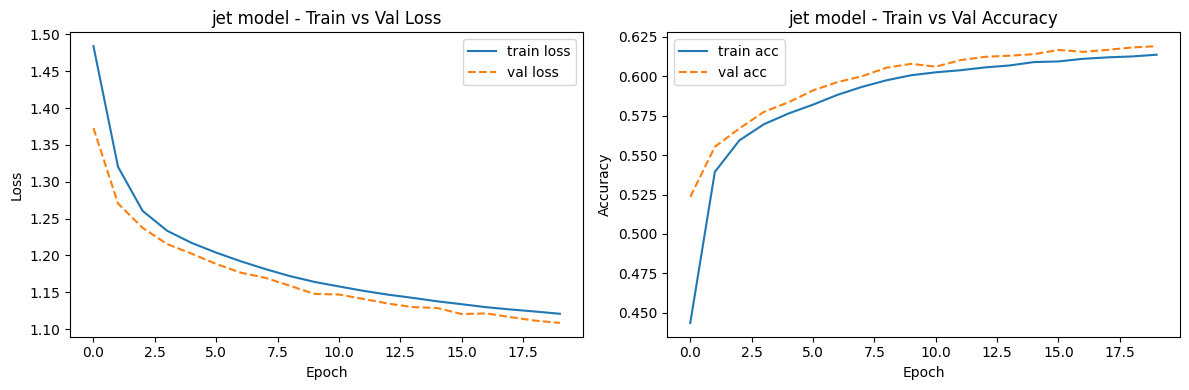

In [42]:
import matplotlib.pyplot as plt
def plot_history(history, name="model", title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)  # 1 row, 2 cols [web:270]

    # Loss
    axes[0].plot(history.history["loss"], label="train loss")
    axes[0].plot(history.history["val_loss"], "--", label="val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title_prefix}{name} - Train vs Val Loss")
    axes[0].legend()

    # Accuracy
    axes[1].plot(history.history["accuracy"], label="train acc")
    axes[1].plot(history.history["val_accuracy"], "--", label="val acc")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{title_prefix}{name} - Train vs Val Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history, name="jet model")


## 5. Prediction Distributions

For each event, the model predicts a probability for all five jet classes rather than a single binary score. This lets us inspect how confidently the network assigns events to each class.

3891/3891 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step


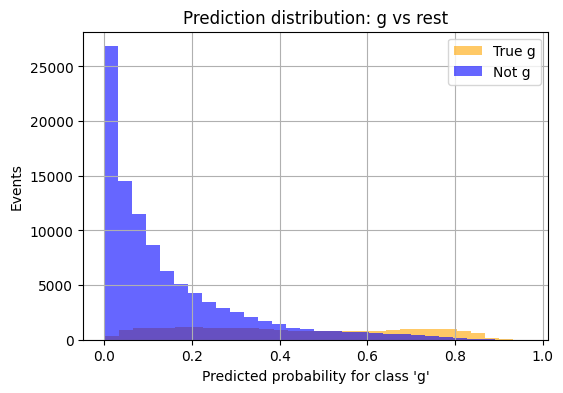

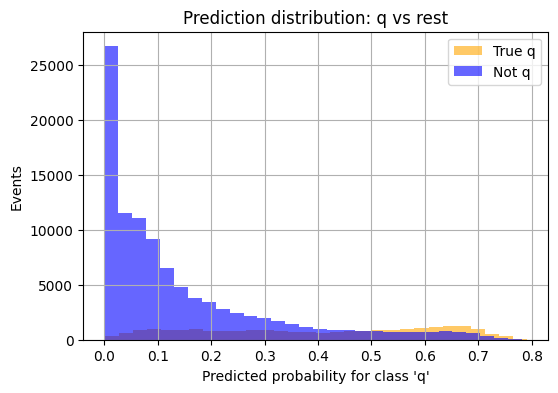

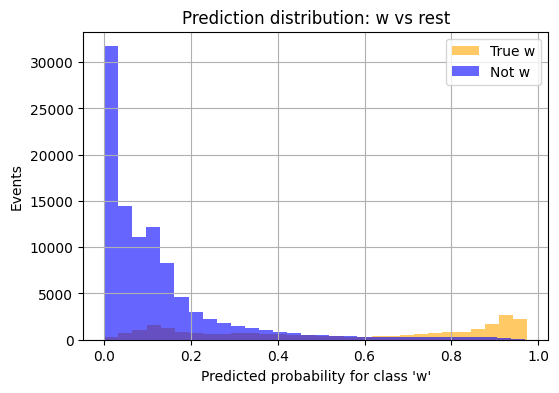

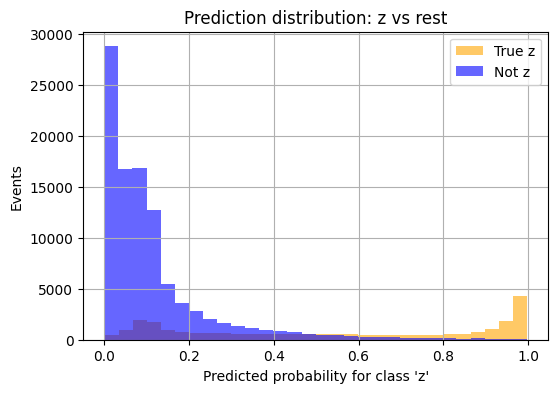

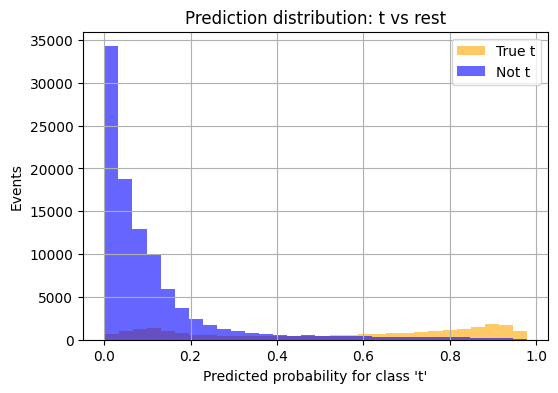

In [43]:
def plot_pred_distribution_multiclass(y_true, y_score, class_names, bins=30):
    for i, class_name in enumerate(class_names):
        plt.figure(figsize=(6, 4))
        plt.hist(y_score[y_true == i, i], bins=bins, alpha=0.6, label=f"True {class_name}", color="orange")
        plt.hist(y_score[y_true != i, i], bins=bins, alpha=0.6, label=f"Not {class_name}", color="blue")
        plt.xlabel(f"Predicted probability for class '{class_name}'")
        plt.ylabel("Events")
        plt.title(f"Prediction distribution: {class_name} vs rest")
        plt.legend()
        plt.grid(True)
        plt.show()

# Predict class probabilities
y_score = model.predict(X_test)
classes = ['g', 'q', 'w', 'z', 't']
plot_pred_distribution_multiclass(y_test, y_score, classes)

## 6. ROC Curve Comparison

We again use ROC curves check whether the trained model is any good.

Accuracy: 0.6169879518072289


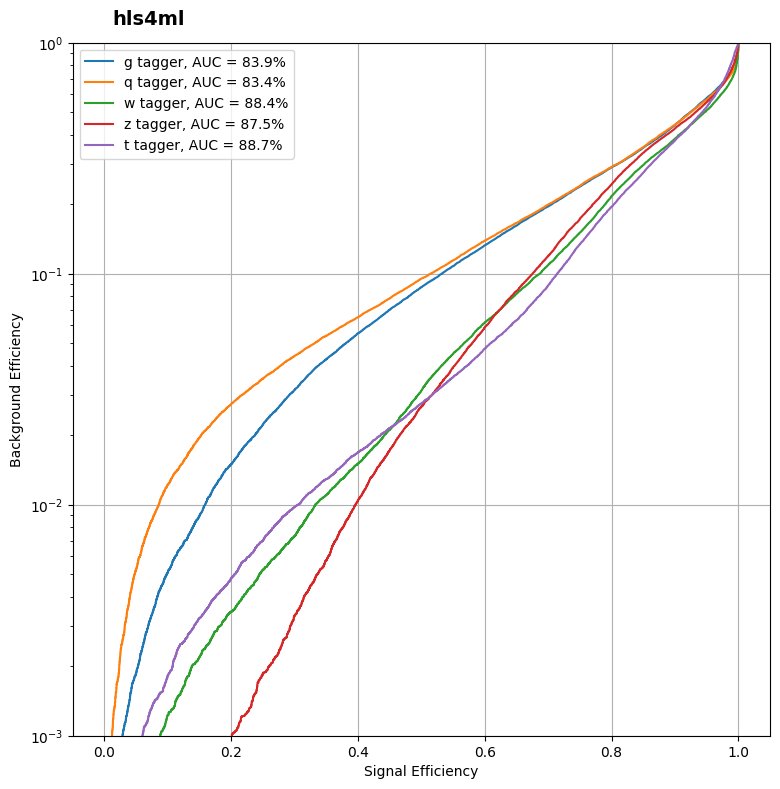

In [44]:
import plotting
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

print("Accuracy: {}".format(accuracy_score(y_test, np.argmax(y_score, axis=1))))
plt.figure(figsize=(9, 9))
_ = plotting.makeRoc(tf.keras.utils.to_categorical(y_test, num_classes=len(classes)), y_score, classes)

### When transformers are not the best models

Transformers are powerful, but they are not always the best model for every task. In this tabular jet-tagging example, the standard neural network and boosted decision trees can outperform the transformer, showing that more complex architectures do not automatically lead to better results.

A key reason is that this dataset contains only 16 engineered high-level jet features. In this setting, the transformer learns relationships between summary features, not between the individual particles inside a jet, so it cannot fully exploit the relational structure that makes self-attention especially useful.

Transformers are usually better suited to data with rich internal structure, such as sequences, sets, or particle-level inputs. For jet physics, their strength becomes much more relevant when using constituent-level data, where the model can directly learn particle-particle interactions through attention.

